# Demonstration neighborhood 
- Author: Minho Kim
- Updated: July 2026

> Kim, M., Raine, H., Radke, J., & González, M. C. *A Network Approach to Mapping Responsibility in Wildfire Risk Mitigation.*

In [11]:
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy import ndimage


import sys
sys.path.insert(0, '../src')

from compute_sr import bldg_to_parcel
from utils import open_asc, group_bldgs_by_parcel

%matplotlib inline

In [12]:
data_path = '../data'
buffer_distance = 30  # feet

bldgs = gpd.read_file(f'{data_path}/bldgs.shp')
parcels = gpd.read_file(f'{data_path}/parcels.shp')

all_bldgs_tax = bldg_to_parcel(bldgs, parcels)
all_bldgs_tax['DS_30'] = all_bldgs_tax.geometry.buffer(buffer_distance / 3.281)
all_bldgs_tax.rename(columns={'geometry': 'bldg_geometry', 'DS_30': 'geometry'}, inplace=True)
all_bldgs_tax = all_bldgs_tax.set_geometry('geometry')
all_bldgs_tax_grouped = group_bldgs_by_parcel(all_bldgs_tax)


100%|██████████| 70/70 [00:00<00:00, 1965.73it/s]


## 2. Study site multi-panel figure
- A: Building footprint, defensile space buffers (30-ft) and parcels
- B, D--G: GIS layers (ASCII files) used for fire behavior modeling in FlamMap
- C: Rate of spread (ROS) output from FlamMap

In [13]:
label_size = 24

fuel_path = f'{data_path}/ASC/fuel_no_mit_11_27_2.asc'
topo_path = f'{data_path}/ASC/topo.asc'
slope_path = f'{data_path}/ASC/slope.asc'
aspect_path = f'{data_path}/ASC/aspect.asc'
risk_pre_path = f'{data_path}/Outputs/ROS_nomit.tif'
lcp_path = f'{data_path}/ASC/LCP/lcp1.lcp'

risk_pre = rasterio.open(risk_pre_path, 'r').read(1)
with rasterio.open(lcp_path) as lcp_src:
    lcp_img = lcp_src.read()


In [14]:
# Fuel model classes and colors
fuel_data = open_asc(fuel_path)
fuel_class_map = {0: "Non\n-Fuel", 1: "Urban", 2: "GS2", 3: "SH7", 4: "SB4"}
fuel_colors = [
    (0, 0, 0),                      # 0 = Non-Fuel
    (0.4078, 0.4078, 0.4078),       # 1 = Urban
    (1.0, 0.6549, 0.4980),          # 2 = GS2
    (0.8039, 0.4902, 0.2235),       # 3 = SH7
    (1.0, 0.4980, 0.4980)           # 4 = SB4
]

unique_classes = np.unique(fuel_data.compressed())
used_colors = [fuel_colors[i] for i, _ in enumerate(unique_classes)]
used_labels = [fuel_class_map[i] for i, _ in enumerate(unique_classes)]
fuel_cmap = ListedColormap(used_colors)
fuel_bounds = np.append(unique_classes - 0.5, unique_classes[-1] + 0.5)
norm = matplotlib.colors.BoundaryNorm(fuel_bounds, len(unique_classes))
tick_positions = (fuel_bounds[:-1] + fuel_bounds[1:]) / 2

# For canopy cover
img_cc = lcp_img[4]

/var/folders/4q/2ngj48zn1b9cn0bd_kz6gg8c0000gn/T/ipykernel_18672/1857769628.py:10: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='lightgrey', edgecolor='k', label="Parcels"),


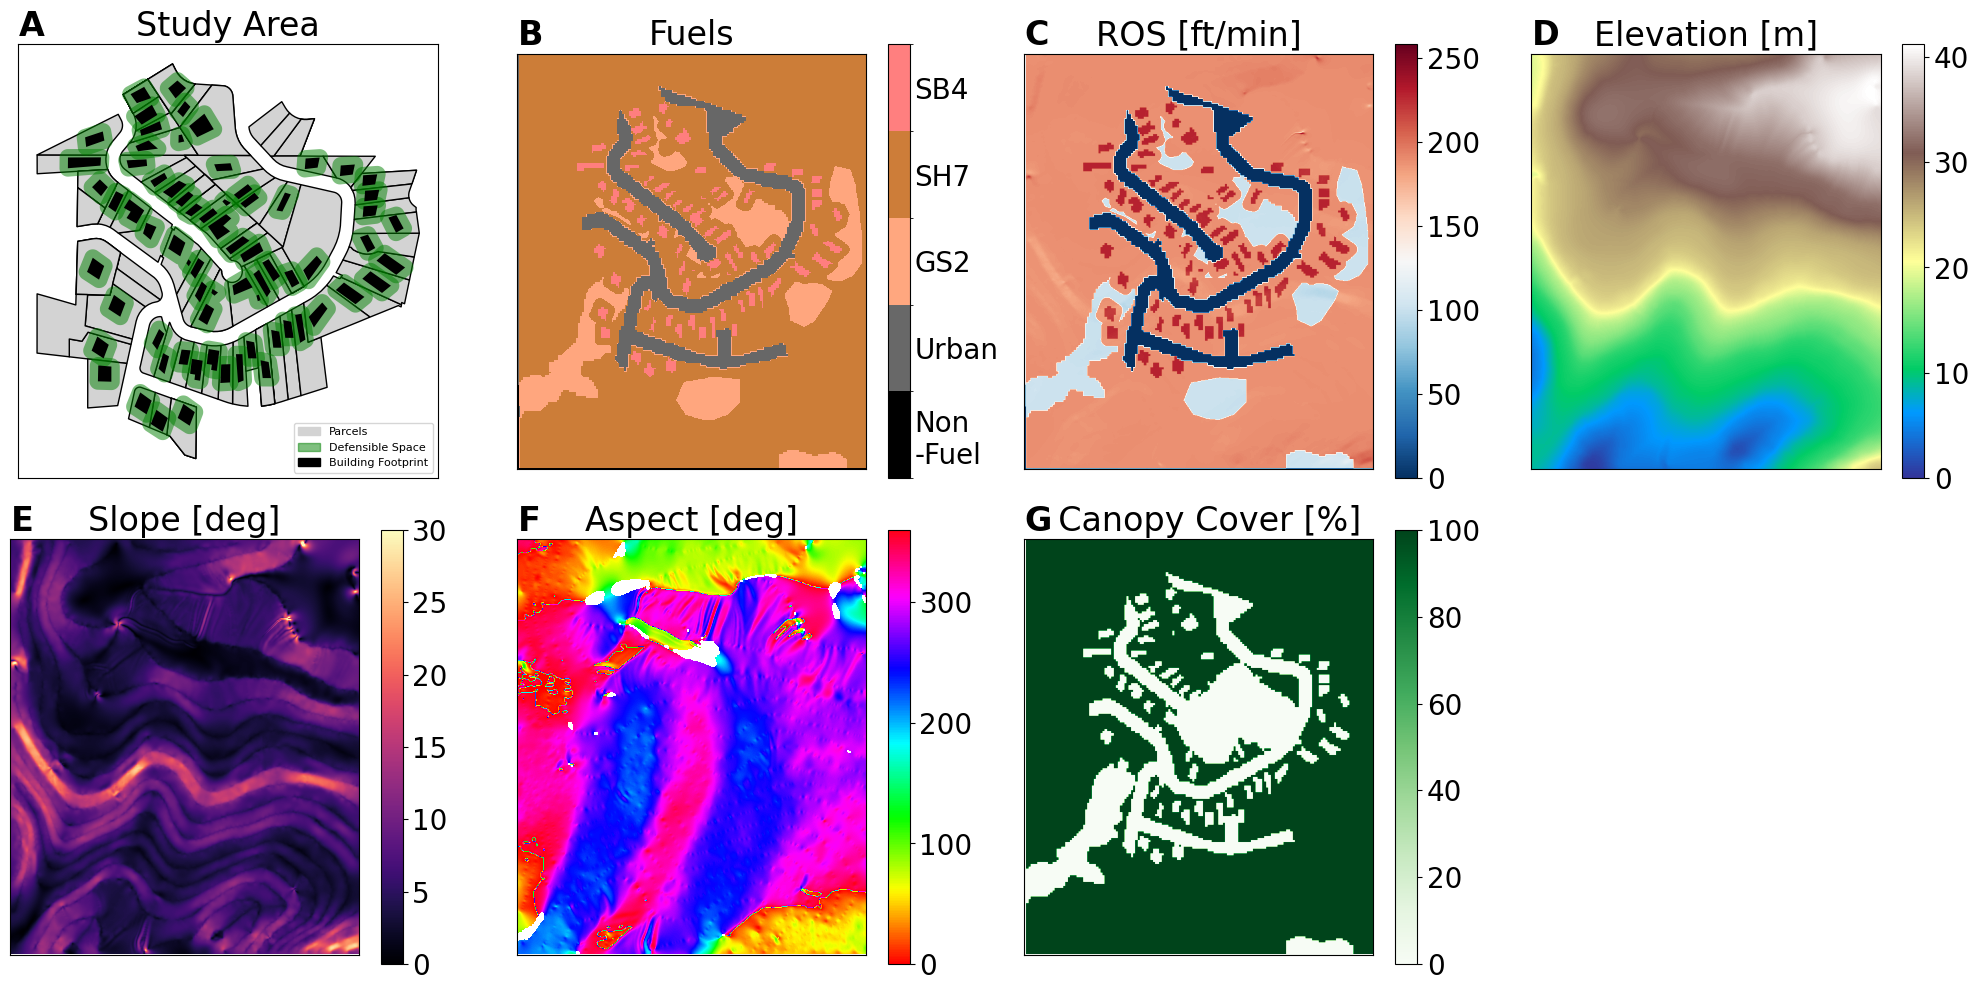

In [15]:
# Viz
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
ax = axs.flatten()

# 0. Study area (A)
parcels.plot(ax=ax[0], color='lightgrey', edgecolor='k')
all_bldgs_tax_grouped.plot(ax=ax[0], color='g', alpha=0.5)
bldgs.plot(ax=ax[0], color='k')
legend_patches = [
    mpatches.Patch(color='lightgrey', edgecolor='k', label="Parcels"),
    mpatches.Patch(color='g', alpha=0.5, label='Defensible Space'),
    mpatches.Patch(color='k', label='Building Footprint')
]
ax[0].legend(handles=legend_patches, fontsize=8, loc='lower right')
ax[0].set_title('Study Area', size=label_size)

# 1. Fuels (B)
im0 = ax[1].imshow(fuel_data, cmap=fuel_cmap, norm=norm)
cbar = fig.colorbar(im0, ax=ax[1], orientation='vertical', ticks=tick_positions)
cbar.ax.set_yticklabels(used_labels, fontsize=20)
cbar.ax.tick_params(length=0)
ax[1].set_title('Fuels', size=label_size)

# 2. Rate of Spread (C)
cax1 = ax[2].imshow(risk_pre, cmap='RdBu_r')
fig.colorbar(cax1, ax=ax[2], orientation='vertical').ax.tick_params(labelsize=20)
ax[2].set_title("ROS [ft/min]", size=label_size)

# 3. Elevation (D)
im6 = ax[3].imshow(open_asc(topo_path), cmap='terrain', vmin=0)
fig.colorbar(im6, ax=ax[3], orientation='vertical').ax.tick_params(labelsize=20)
ax[3].set_title('Elevation [m]', size=label_size)

# 4. Slope (E)
im7 = ax[4].imshow(open_asc(slope_path), cmap='magma', vmin=0, vmax=30)
fig.colorbar(im7, ax=ax[4], orientation='vertical').ax.tick_params(labelsize=20)
ax[4].set_title('Slope [deg]', size=label_size)

# 5. Aspect (F)
elevation = open_asc(topo_path)
cellsize = 30
dzdx = ndimage.sobel(elevation, axis=1) / (8 * cellsize)
dzdy = ndimage.sobel(elevation, axis=0) / (8 * cellsize)
aspect = np.degrees(np.arctan2(dzdx, dzdy))
aspect = (90.0 - aspect) % 360
slope = open_asc(slope_path)
aspect[slope < 1] = np.nan
im8 = ax[5].imshow(aspect, cmap='hsv', vmin=0, vmax=360)
fig.colorbar(im8, ax=ax[5], orientation='vertical').ax.tick_params(labelsize=20)
ax[5].set_title('Aspect [deg]', size=label_size)

# 6. Canopy cover (G) -- scaled to 0-100%
im_cc = ax[6].imshow(img_cc * 100, cmap='Greens', vmin=0, vmax=100)
fig.colorbar(im_cc, ax=ax[6], orientation='vertical').ax.tick_params(labelsize=20)
ax[6].set_title('  Canopy Cover [%]', size=label_size)


ax[7].axis('off')
for i in range(7):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

panel_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
for i, label in enumerate(panel_labels):
    ax[i].set_title(rf"$\bf{{{label}}}$", size=label_size, loc='left')

plt.tight_layout()

save_path = None
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()